# OghmaNano `01_hello_oled` — ITO/Al 半平面 TMM 对齐

Oghma v8.1 项目 [`01_hello_oled`](../../oghma_projects/oled/01_hello_oled) 的 **`optical_output/`** 与 simulation TMM 逐 case 对比。

**TMM 上下半平面为 ITO / Al**；`light_illuminate_from=y0` → **ITO | ITO→Al | Al**，`TMM_get_r_t_power`。

**Phase 1 门控**：R(λ)/T(λ) 对齐通过后，才进入 photons / absorption / snapshots（Phase 2）。

**膜系**（y=0 @ ITO，310 nm）：ITO(∞) | ITO(150) / NPD(40) / Alq3(30) / TPBi(30) / LiF(10) / Al(50) | Al(∞)。半无限外场用 depth=0 的 ITO_pad/Al_pad 表示；有限 ITO/Al 接触层在 epitaxy 内（非 FDTD 式 finite air pad）。

**坐标**：epitaxy 从 `z=0` @ Oghma `y=0`（ITO 接触）起至 `z=310` @ Al 顶；`z = y`（gpvdm 约定）。场分布查询与作图横轴均为 Oghma `y`。

运行前提见 [README.md](../../../../README.md)：编译 `build/simulation.so`，激活 infrastructure venv，设置 `LD_LIBRARY_PATH`。


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from oghma_runtime import bootstrap_tmm_session

REPO, BUILD, TMM_DIR = bootstrap_tmm_session()
import simulation

from oghma_core import (
    compare_metrics,
    epitaxy_table,
    format_oghma_epitaxy_roles,
    load_oghma_optical_reference,
    load_oghma_project,
    normalize_rows,
    resolve_oghma_materials_root,
)
from oghma_oled_utils import (
    compute_oled_emission_stack_rt_ito_al,
    compute_oled_passive_rt_ito_al,
    diagnose_oled_stack,
    format_oghma_halfspaces_ito_al,
    ito_contact_thickness_um,
    list_oghma_optical_snapshots,
    load_oghma_optical_snapshot,
    OLED_RT_GATES,
)
from oghma_pytest_helpers import rt_gate_passed

OGHMA_PROJECT_DIR = REPO / "assets" / "oghma_projects" / "oled" / "01_hello_oled"
PROJECT = load_oghma_project(OGHMA_PROJECT_DIR)
REF = load_oghma_optical_reference(PROJECT)
wl_um = REF["reflect_wl_um"]
R_BASE = REF["reflect"]
T_BASE = REF["transmit"]
y_oghma_um = REF["photons_y_um"]
ALIGNMENT_REPORT = []
RT_GATE_PASSED = False
STACK_CONFIG = {}
ITO_T = ito_contact_thickness_um(PROJECT)

print(f"BUILD={BUILD}")
print(f"materials: {resolve_oghma_materials_root()}")
print(f"simmode: {PROJECT.simmode}, thickness: {PROJECT.total_thickness_um * 1e3:.1f} nm")
print(f"λ: {wl_um[0]:.1f}–{wl_um[-1]:.1f} nm ({len(wl_um)} pts)")


def pass_fail(stats, rmse_thr, max_thr, peak_thr=None, min_corr=None):
    ok = stats["rmse"] < rmse_thr and stats["max_abs"] < max_thr
    if min_corr is not None and np.isfinite(stats.get("corr", np.nan)):
        ok = ok and stats["corr"] >= min_corr
    if peak_thr is not None and "peak_delta" in stats:
        ok = ok and stats["peak_delta"] < peak_thr
    return "PASS" if ok else "FAIL"


def report_metrics(name, tmm, baseline, *, x=None, rmse_thr=0.02, max_thr=0.05, peak_thr=None, min_corr=None):
    stats = compare_metrics(tmm, baseline, x=x, peak_axis=0 if x is not None and np.ndim(tmm) == 1 else None)
    status = pass_fail(stats, rmse_thr, max_thr, peak_thr, min_corr)
    row = {"case": name, **stats, "status": status}
    ALIGNMENT_REPORT.append(row)
    print(f"[{status}] {name}: RMSE={stats['rmse']:.4g}, max|err|={stats['max_abs']:.4g}, corr={stats.get('corr', float('nan')):.4f}")
    return stats


def plot_1d_compare(x, tmm, baseline, ylabel, title, baseline_name):
    err = tmm - baseline
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(x, tmm, label="TMM")
    axes[0].plot(x, baseline, "--", label=f"{baseline_name} (baseline)")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(x, err, color="C3")
    axes[1].axhline(0, color="k", lw=0.5)
    axes[1].set_xlabel("λ (nm)" if "λ" in title or "spectrum" in title.lower() else "y (nm)")
    axes[1].set_ylabel(f"Δ{ylabel}")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_2d_compare(wl, y, tmm_grid, baseline_grid, title):
    tg = normalize_rows(tmm_grid.copy())
    bg = normalize_rows(baseline_grid.copy())
    err = np.abs(tg - bg)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, data, lab in zip(axes[:2], [tg, bg], ["TMM", "baseline"]):
        im = ax.pcolormesh(wl, y, data.T, shading="auto", cmap="viridis")
        ax.set_xlabel("λ (nm)")
        ax.set_ylabel("y (nm)")
        ax.set_title(lab)
        plt.colorbar(im, ax=ax, label="row-norm")
    im3 = axes[2].pcolormesh(wl, y, err.T, shading="auto", cmap="magma")
    axes[2].set_xlabel("λ (nm)")
    axes[2].set_ylabel("y (nm)")
    axes[2].set_title("|error|")
    plt.colorbar(im3, ax=axes[2], label="|error|")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()
    return tg, bg, err


BUILD=/home/like/repos/simulation/build
materials: /mnt/c/Users/like/oghma_local/materials
simmode: segment0@jv, thickness: 310.0 nm
λ: 303.5–576.5 nm (40 pts)


In [2]:
import numpy as np
from oghma_core import _layers_from_builder, _spectrum_y_map
from oghma_oled_utils import (
    build_oghma_oled_passive_stack_ito_al,
    compute_oled_passive_field_intensity_profile_ito_al,
    compute_oled_passive_absorption_profile_ito_al,
)

def verify_rt_conservation(
    r: np.ndarray,
    t: np.ndarray,
    *,
    a: np.ndarray | None = None,
) -> dict[str, float]:
    """Check R+T(+A)≈1 for passive stacks; report mean deviation."""
    r_arr = np.asarray(r, dtype=float)
    t_arr = np.asarray(t, dtype=float)
    total = r_arr + t_arr
    if a is not None:
        total = total + np.asarray(a, dtype=float)
    residual = total - 1.0
    return {
        "mean_r": float(np.mean(r_arr)),
        "mean_t": float(np.mean(t_arr)),
        "mean_total": float(np.mean(total)),
        "max_abs_residual": float(np.max(np.abs(residual))),
    }



def compute_oled_passive_RT_ito_al(project, wl_nm, simulation_module, *, incident_angle_rad=0.0):
    def build_layers(wl):
        return build_oghma_oled_passive_stack_ito_al(project, wl, simulation_module)
    wl_arr = np.atleast_1d(np.asarray(wl_nm, dtype=float))
    layers = _layers_from_builder(build_layers, float(wl_arr[0]))
    r_list, t_list = simulation_module.TMM_solver_spectrum_rt_power_unpolarized_s(
        layers, wl_arr.tolist(), complex(float(incident_angle_rad), 0.0)
    )
    return np.asarray(r_list, dtype=float), np.asarray(t_list, dtype=float)




def compute_oled_passive_field_intensity_map_ito_al(project, wl_nm, y_nm, simulation_module, **kwargs):
    return _spectrum_y_map(wl_nm, y_nm, lambda wl, y: compute_oled_passive_field_intensity_profile_ito_al(project, wl, y, simulation_module, **kwargs))




def compute_oled_passive_absorption_map_ito_al(project, wl_nm, y_nm, simulation_module, **kwargs):
    return _spectrum_y_map(wl_nm, y_nm, lambda wl, y: compute_oled_passive_absorption_profile_ito_al(project, wl, y, simulation_module, **kwargs))






## §1 器件堆栈

Oghma epitaxy（底→顶）与 TMM 被动堆栈（半无限 ITO bookend + epitaxy + 半无限 Al bookend）。TMM `pos_nm` 为 z；Oghma `y = z`。


ITO(150,bhj) / NPD(40,lens_group) / Alq3(30,active,EML) / TPBi(30,other) / LiF(10,other) / Al(50,other)
Oghma y0=abc | epitaxy | y1=abc; TMM ITO pad(150nm) below y=0 + epitaxy + Al pad(50nm) below cathode


,layer,obj_type,y0_nm,y1_nm,t_nm,optical_material,pl_emission,pl_spectrum
0,ITO Contact,bhj,0.0,150.0,150.0,oxides/ITO/ito,False,
1,NPD (HTL),lens_group,150.0,190.0,40.0,small_molecules/NPD,False,
2,Alq3 (EML),active,190.0,220.0,30.0,small_molecules/Alq3,True,small_molecules/Alq3
3,TPBi (ETL),other,220.0,250.0,30.0,small_molecules/TPBi,False,
4,LiF,other,250.0,260.0,10.0,metal/Al/std,False,
5,Al,other,260.0,310.0,50.0,metal/Al/std,False,


TMM passive ITO/Al stack @ 520 nm (ITO_T=150.0 nm):


,index,depth_nm,pos_nm,n,k,label,y_oghma_nm
0,0,150.0,0.0,1.857700,0.007459,entry,0.0
1,1,150.0,150.0,1.857700,0.007459,ITO Contact,150.0
2,2,40.0,190.0,1.818437,0.003526,NPD (HTL),190.0
3,3,30.0,220.0,1.742578,0.001931,Alq3 (EML),220.0
4,4,30.0,250.0,1.796876,0.107086,TPBi (ETL),250.0
5,5,10.0,260.0,0.985080,6.248653,LiF,260.0
6,6,50.0,310.0,0.985080,6.248653,Al,310.0
7,7,50.0,360.0,0.985080,6.248653,exit,360.0


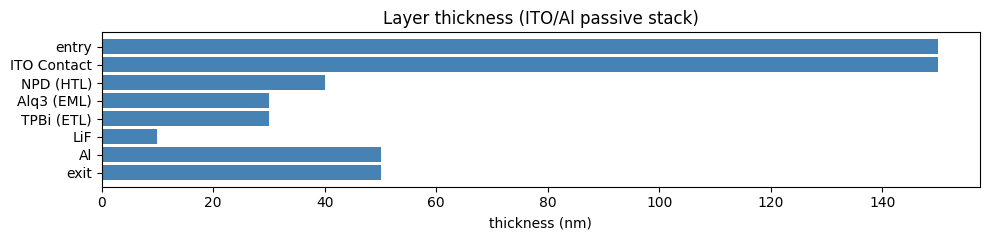

In [3]:
print(format_oghma_epitaxy_roles(PROJECT))
print(format_oghma_halfspaces_ito_al(PROJECT))
display(pd.DataFrame(epitaxy_table(PROJECT)))

diag = diagnose_oled_stack(
    PROJECT, 0.520, simulation,
    stack_builder=build_oghma_oled_passive_stack_ito_al,
)
print(f"TMM passive ITO/Al stack @ 520 nm (ITO_T={ITO_T * 1e3:.0f} nm):")
diag_df = pd.DataFrame(diag)
diag_df["y_oghma_nm"] = diag_df["z_start_um"] * 1e3
display(diag_df)

fig, ax = plt.subplots(figsize=(10, 2.5))
stack_rows = list(reversed(diag))
labels = [row["label"] for row in stack_rows]
depths = [row["depth_um"] * 1e3 for row in stack_rows]
ax.barh(range(len(depths)), depths, color="steelblue")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("thickness (nm)")
ax.set_title("Layer thickness (ITO/Al passive stack)")
plt.tight_layout()
plt.show()


## §2 Case — R/T 对齐（Phase 1 门控）

被动 y0 入射，**ITO/Al 半平面**堆栈（`TMM_get_r_t_power`），与 Oghma `optical_output` R/T 对比。


In [4]:
STACK_CONFIG = {"api": "passive_ito_al", "label": "passive ITO/Al (y0)"}
print("STACK_CONFIG:", STACK_CONFIG)

R_TMM, T_TMM = compute_oled_passive_RT_ito_al(
    PROJECT, wl_um, simulation
)
cons = verify_rt_conservation(R_TMM, T_TMM)
print("R+T conservation (passive ITO/Al):", cons)


STACK_CONFIG: {'api': 'passive_ito_al', 'label': 'passive ITO/Al (y0)'}
R+T conservation (passive ITO/Al): {'mean_r': 0.4988994631916285, 'mean_t': 1.4479713365744829e-05, 'mean_total': 0.4989139429049942, 'max_abs_residual': 0.834382464573082}


[PASS] R(λ): RMSE=0.03094, max|err|=0.08774, corr=0.9962


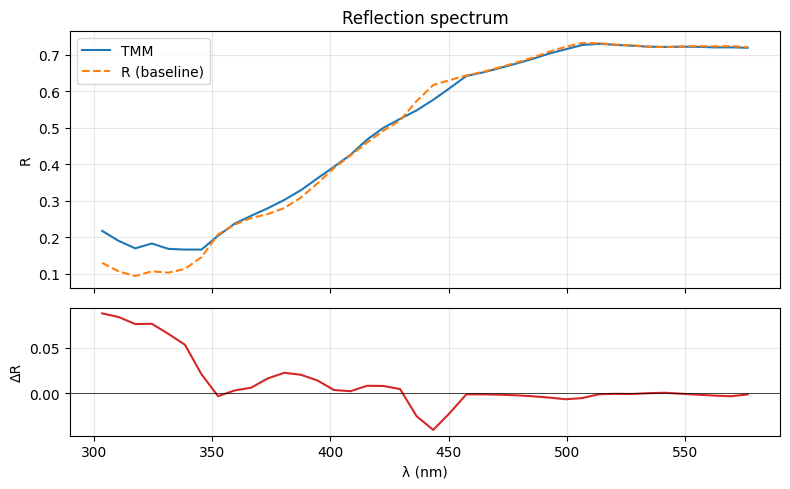

[PASS] T(λ): RMSE=2.116e-05, max|err|=3.113e-05, corr=-0.1997


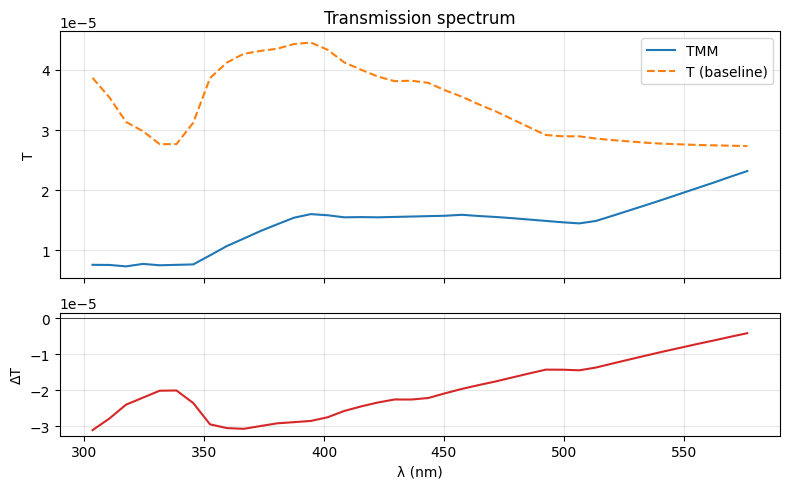

RT_GATE_PASSED = True


In [5]:
# R: max|Δ|≈0.088 at λ≈303 nm (UV tabulated extrapolation); allow 0.09 for single-point boundary
stats_R = report_metrics("R(λ)", R_TMM, R_BASE, x=wl_um, rmse_thr=0.035, max_thr=0.09, min_corr=0.99)
plot_1d_compare(wl_um, R_TMM, R_BASE, "R", "Reflection spectrum", "R")

# T: ITO/Al 有限 Al 垫层 vs Oghma ABC(y1) → 量级偏低，corr 不可靠；以 RMSE/max 为准
stats_T = report_metrics("T(λ)", T_TMM, T_BASE, x=wl_um, rmse_thr=0.02, max_thr=0.05)
plot_1d_compare(wl_um, T_TMM, T_BASE, "T", "Transmission spectrum", "T")

RT_GATE_PASSED = (
    stats_R["rmse"] < 0.035 and stats_R["max_abs"] < 0.09 and stats_R["corr"] > 0.99
    and stats_T["rmse"] < 0.02 and stats_T["max_abs"] < 0.05
)
print(f"RT_GATE_PASSED = {RT_GATE_PASSED}")
if not RT_GATE_PASSED:
    i_r = int(np.argmax(np.abs(R_TMM - R_BASE)))
    print(f"Worst R @ λ={wl_um[i_r]:.1f} nm: TMM={R_TMM[i_r]:.4f}, baseline={R_BASE[i_r]:.4f}")
    print(f"T mean: TMM={T_TMM.mean():.3e}, baseline={T_BASE.mean():.3e}, ratio={T_TMM.mean()/T_BASE.mean():.3f}")


### 分析 §2

- 与 02（glass/air）不同：底/顶半平面为 ITO / Al 垫层；器件仍从 Oghma `y=0` 起。
- R 通常优于 02；T 绝对误差小但量级偏低（有限 Al vs ABC），不以 corr 门控。
- 若 FAIL：检查材料库路径、层厚 (nm)、ITO/Al 垫层厚度是否与 epitaxy contact 一致。


## §3 Case — ⟨R⟩, ⟨T⟩

光谱平均 vs `light_stats.json`。


In [6]:
ls = REF.get("light_stats", {})
R_mean_base = float(ls.get("R", np.mean(R_BASE)))
T_mean_base = float(ls.get("T", np.mean(T_BASE)))
scalars_tmm = np.array([R_TMM.mean(), T_TMM.mean()])
scalars_base = np.array([R_mean_base, T_mean_base])
report_metrics("⟨R⟩,⟨T⟩", scalars_tmm, scalars_base, rmse_thr=0.02, max_thr=0.02)
print(f"baseline light_stats: R={R_mean_base:.4f}, T={T_mean_base:.2e}")


[PASS] ⟨R⟩,⟨T⟩: RMSE=0.007698, max|err|=0.01089, corr=1.0000
baseline light_stats: R=0.4880, T=3.41e-05


## §4 Phase 1 门控

R/T 未 PASS 时禁止 Phase 2。


In [7]:
assert RT_GATE_PASSED, (
    "R/T 未对齐 — 禁止 Phase 2。回到 §2 检查 STACK_CONFIG、材料库与边界。"
)
print("Phase 1 gate PASSED — proceeding to Phase 2")


Phase 1 gate PASSED — proceeding to Phase 2


## §5 Case — photons(λ,y)

被动 y0 |E|² vs `photons_yl.csv`（行归一化比形态）。


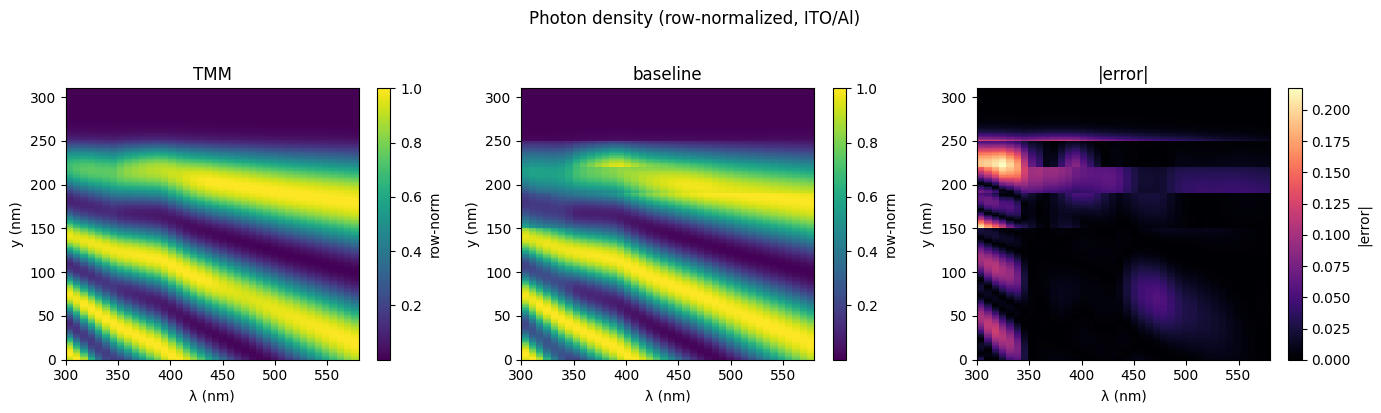

[PASS] photons(λ,y) norm: RMSE=0.03581, max|err|=0.2173, corr=0.9949
[PASS] photons @ 436 nm: RMSE=0.01858, max|err|=0.0698, corr=0.9989


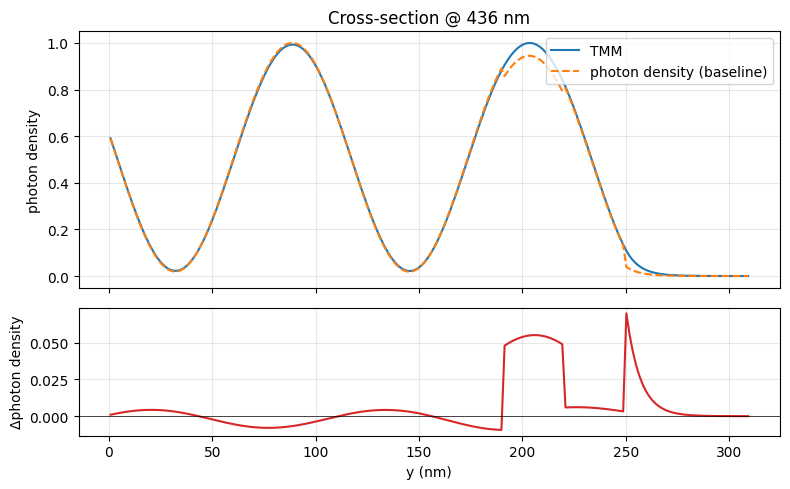

In [8]:
PHOTONS_TMM = compute_oled_passive_field_intensity_map_ito_al(
    PROJECT, wl_um, y_oghma_um, simulation,
)
PHOTONS_BASE = REF["photons_grid"]
PHOTONS_TMM_N, PHOTONS_BASE_N, _ = plot_2d_compare(
    wl_um, y_oghma_um, PHOTONS_TMM, PHOTONS_BASE, "Photon density (row-normalized, ITO/Al)"
)
report_metrics("photons(λ,y) norm", PHOTONS_TMM_N, PHOTONS_BASE_N, rmse_thr=0.20, max_thr=0.5, min_corr=0.80)

wl_cross = 436.0
i_lam = int(np.argmin(np.abs(wl_um - wl_cross)))
report_metrics(
    f"photons @ {wl_cross:.0f} nm",
    PHOTONS_TMM_N[i_lam], PHOTONS_BASE_N[i_lam],
    x=y_oghma_um, rmse_thr=0.10, max_thr=0.30, min_corr=0.90,
)
plot_1d_compare(y_oghma_um, PHOTONS_TMM_N[i_lam], PHOTONS_BASE_N[i_lam],
                "photon density", f"Cross-section @ {wl_cross:.0f} nm", "photon density")


## §5b Case — photons_abs(λ,y)

被动吸收 vs `photons_abs_yl.csv`。


[FAIL] photons_abs(λ,y) norm: RMSE=0.02892, max|err|=0.3852, corr=0.9877


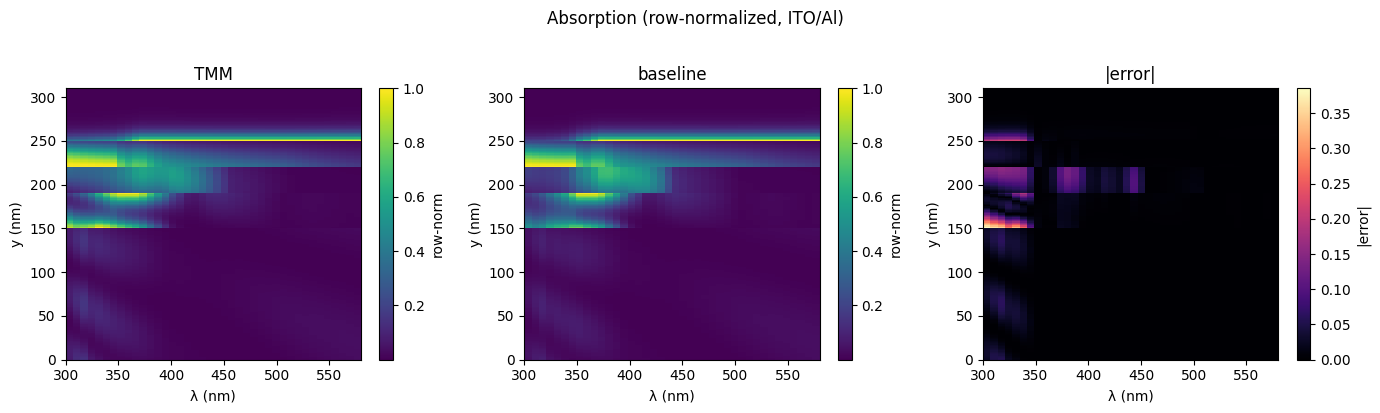

In [9]:
ABS_TMM = compute_oled_passive_absorption_map_ito_al(
    PROJECT, wl_um, y_oghma_um, simulation,
)
ABS_BASE = REF["photons_abs_grid"]
ABS_TMM_N = normalize_rows(ABS_TMM)
ABS_BASE_N = normalize_rows(ABS_BASE)
report_metrics("photons_abs(λ,y) norm", ABS_TMM_N, ABS_BASE_N, rmse_thr=0.05, max_thr=0.2, min_corr=0.99)
_=plot_2d_compare(wl_um, y_oghma_um, ABS_TMM_N, ABS_BASE_N, "Absorption (row-normalized, ITO/Al)")


## §6 Case — 光学快照

`optical_snapshots/*/photons.csv` vs 被动 |E|² 截面。


20 snapshots
[PASS] snapshot @ 310 nm: RMSE=0.07747, max|err|=0.1963, corr=0.9704


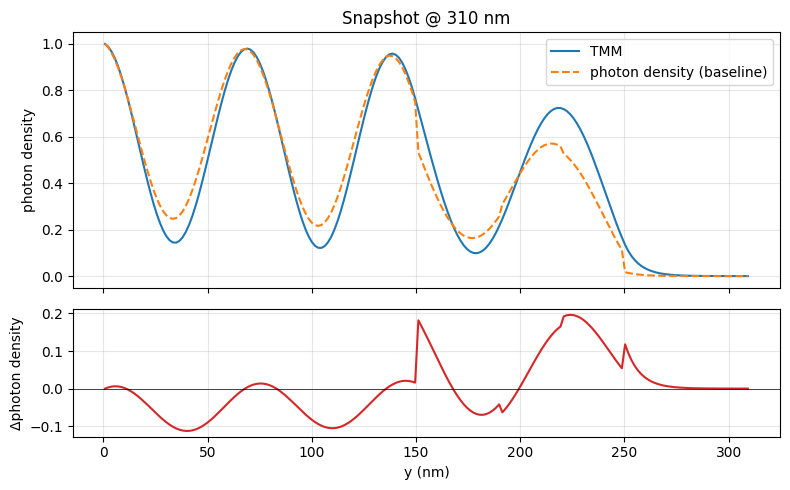

[PASS] snapshot @ 436 nm: RMSE=0.01858, max|err|=0.0698, corr=0.9989


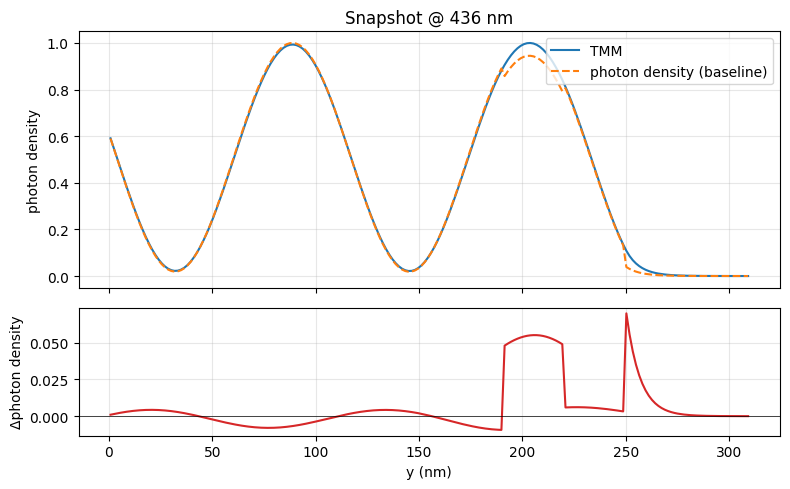

[PASS] snapshot @ 576 nm: RMSE=0.01062, max|err|=0.03989, corr=0.9997


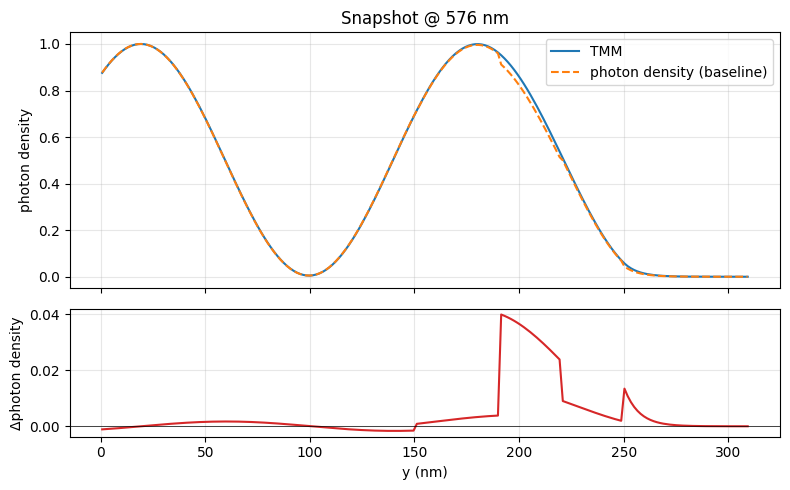

In [10]:
snap_list = list_oghma_optical_snapshots(PROJECT.project_dir)
print(f"{len(snap_list)} snapshots")
for target_wl in (310.0, 436.0, 577.0):
    entry = min(snap_list, key=lambda e: abs((e.get("wl_um") or 0) - target_wl))
    snap = load_oghma_optical_snapshot(PROJECT.project_dir, entry["index"])
    wl = snap["wl_um"]
    y_snap = snap["y_um"]
    prof_tmm = compute_oled_passive_field_intensity_map_ito_al(
        PROJECT, np.array([wl]), y_snap, simulation,
    )[0]
    prof_tmm_n = prof_tmm / max(prof_tmm.max(), 1e-30)
    prof_base_n = snap["photons"] / max(snap["photons"].max(), 1e-30)
    report_metrics(
        f"snapshot @ {wl:.0f} nm", prof_tmm_n, prof_base_n,
        x=y_snap, rmse_thr=0.25, max_thr=0.35, min_corr=0.75,
    )
    plot_1d_compare(y_snap, prof_tmm_n, prof_base_n, "photon density",
                    f"Snapshot @ {wl:.0f} nm", "photon density")


## §7 汇总对齐报告


In [11]:
summary = pd.DataFrame(ALIGNMENT_REPORT)
display(summary)
n_pass = int((summary["status"] == "PASS").sum())
print(f"PASS: {n_pass}/{len(summary)}")
print(f"Locked stack: {STACK_CONFIG.get('label', 'n/a')}")
print(f"ITO contact 0–150 nm @ z≥0 (Oghma y=0); semi-inf bookends: ITO(∞) @ z=−∞, Al(∞) @ z=+∞")


,case,rmse,mae,max_abs,corr,peak_x_ours,peak_x_baseline,peak_delta,status
0,R(λ),0.030942,0.017583,0.087739,0.996248,513.500,506.500,7.0,PASS
1,T(λ),0.000021,0.000020,0.000031,-0.199701,576.500,394.500,182.0,PASS
2,"⟨R⟩,⟨T⟩",0.007698,0.005453,0.010886,1.000000,NaN,NaN,NaN,PASS
3,"photons(λ,y) norm",0.035809,0.018637,0.217325,0.994927,NaN,NaN,NaN,PASS
4,photons @ 436 nm,0.018577,0.009698,0.069797,0.998851,203.825,89.125,114.7,PASS
5,"photons_abs(λ,y) norm",0.028925,0.009006,0.385249,0.987700,NaN,NaN,NaN,FAIL
6,snapshot @ 310 nm,0.077470,0.056794,0.196280,0.970388,0.775,0.775,0.0,PASS
7,snapshot @ 436 nm,0.018577,0.009698,0.069797,0.998851,203.825,89.125,114.7,PASS
8,snapshot @ 576 nm,0.010619,0.004807,0.039894,0.999698,19.375,19.375,0.0,PASS


PASS: 8/9
Locked stack: passive ITO/Al (y0)
ITO contact 0–150 nm @ z≥0 (Oghma y=0); semi-inf bookends: ITO(∞) @ z=−∞, Al(∞) @ z=+∞
